# Subgraph 추가 및 사용 방법

서브그래프(SubGraph)를 사용하면 여러 구성 요소를 포함하는 복잡한 시스템을 구축할 수 있으며, 이러한 구성 요소 자체가 그래프가 될 수 있습니다. 서브그래프의 가장 대표적인 활용 사례는 독립적인 역할을 수행하는 에이전트들을 하나의 워크플로우로 조합하는 **멀티 에이전트 시스템** 구축입니다.

서브그래프를 추가할 때 핵심 고려사항은 상위 그래프와 서브그래프가 어떻게 **통신**하는지, 즉 그래프 실행 중에 상태(State)를 서로 어떻게 전달하는지입니다. 두 그래프 간 통신 방식에 따라 서브그래프를 추가하는 방법이 달라집니다.

> 📖 **참고 문서**: [LangGraph Graph API](https://docs.langchain.com/oss/python/langgraph/graph-api)

다음 두 가지 시나리오에 따라 서브그래프를 추가하는 방식이 달라집니다.

* 상위 그래프와 서브그래프가 **스키마 키를 공유**하는 경우: 컴파일된 서브그래프를 노드로 직접 추가할 수 있습니다.
* 상위 그래프와 서브그래프가 **서로 다른 스키마**를 가지는 경우: 서브그래프를 호출하는 노드 함수를 별도로 정의해야 합니다.

아래에서 각 시나리오에 대한 구체적인 구현 방법을 살펴보겠습니다.

## 환경 설정

서브그래프 구현을 위한 환경을 설정합니다. 환경 변수를 로드하고 LangSmith 추적을 활성화합니다.

아래 코드에서는 환경 설정을 수행합니다.

In [1]:
# API 키를 환경변수로 관리하기 위한 설정 파일
from dotenv import load_dotenv

# API 키 정보 로드
load_dotenv(override=True)

True

In [2]:
# LangSmith 추적을 설정합니다. https://smith.langchain.com
# !pip install -qU langchain-teddynote
from langchain_teddynote import logging

# 프로젝트 이름을 입력합니다.
logging.langsmith("LangGraph-V1-Tutorial")

LangSmith 추적을 시작합니다.
[프로젝트명]
LangGraph-V1-Tutorial


## Case 1: 스키마 키를 공유하는 경우

상위 그래프와 서브그래프가 공유 상태 키(State Key)를 통해 통신하는 것이 가장 일반적인 사례입니다. 예를 들어, 멀티 에이전트 시스템에서 에이전트들은 주로 공유된 `messages` 키를 통해 서로 메시지를 주고받습니다.

이 방식의 핵심은 **컴파일된 서브그래프를 `.add_node()`에 직접 전달**하는 것입니다. 두 그래프가 같은 키를 공유하기 때문에 LangGraph가 공유 키를 통해 상태를 자동으로 전달하며, 별도의 변환 코드가 필요하지 않습니다.

서브그래프가 상위 그래프와 상태 키를 공유하는 경우, 다음 단계에 따라 그래프에 추가합니다.

1. 서브그래프 워크플로우를 정의하고(아래 예시의 `subgraph_builder`) 컴파일
2. 상위 그래프 워크플로우를 정의할 때 `.add_node` 메서드에 컴파일된 서브그래프를 전달

아래 코드에서는 서브그래프의 상태(`ChildState`)와 노드 함수를 정의하고, 서브그래프를 컴파일합니다.

In [3]:
from langgraph.graph import START, END, StateGraph
from typing import TypedDict


# 서브그래프 상태 정의: 부모 그래프와 공유되는 name 키와 서브그래프 전용 family_name 키 포함
class ChildState(TypedDict):
    name: str        # 부모 그래프(ParentState)와 공유되는 상태 키
    family_name: str # 서브그래프 내부에서만 사용되는 전용 상태 키


# 서브그래프의 첫 번째 노드: family_name 키에 성(姓) 값을 설정
def subgraph_node_1(state: ChildState):
    """서브그래프 첫 번째 노드

    family_name 키에 고정 값을 설정합니다.
    이 값은 subgraph_node_2에서 공유 키 name과 결합됩니다.
    """
    return {"family_name": "Lee"}


# 서브그래프의 두 번째 노드: 공유 name 키와 전용 family_name 키를 결합하여 full name 생성
def subgraph_node_2(state: ChildState):
    """서브그래프 두 번째 노드

    부모 그래프와 공유되는 name 키와 서브그래프 전용 family_name 키를 결합하여
    새로운 name 값을 생성합니다. 갱신된 name은 공유 키이므로 부모 그래프에 전달됩니다.
    """
    # 공유 키(name)와 서브그래프 전용 키(family_name)를 결합
    return {"name": f'{state["name"]} {state["family_name"]}'}


# 서브그래프 구조 정의 및 노드 간 연결 관계 설정
subgraph_builder = StateGraph(ChildState)
subgraph_builder.add_node(subgraph_node_1)
subgraph_builder.add_node(subgraph_node_2)
subgraph_builder.add_edge(START, "subgraph_node_1")
subgraph_builder.add_edge("subgraph_node_1", "subgraph_node_2")
subgraph = subgraph_builder.compile()

### 서브그래프 시각화

컴파일된 서브그래프를 시각화합니다. `xray=True` 옵션을 사용하면 서브그래프 내부의 노드 구조를 확인할 수 있습니다. `subgraph_node_1`에서 `subgraph_node_2`로 순차적으로 실행되는 구조입니다.

아래 코드는 서브그래프를 시각화합니다.

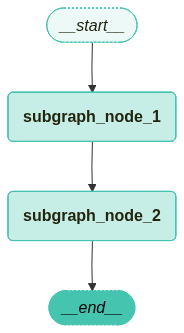

In [4]:
from langchain_teddynote.graphs import visualize_graph

visualize_graph(subgraph, xray=True)

### 부모 그래프 정의

서브그래프가 준비되었으면, 이를 포함하는 부모 그래프를 정의합니다. 부모 그래프의 상태(`ParentState`)는 서브그래프 상태(`ChildState`)와 `name` 키를 공유합니다. `node_1`은 입력받은 이름을 가공하고, `node_2`에는 컴파일된 서브그래프가 직접 등록됩니다.

컴파일된 서브그래프를 노드로 추가할 때는 `builder.add_node("node_2", subgraph)`와 같이 서브그래프 객체를 직접 전달하면 됩니다. LangGraph가 공유 키(`name`)를 통해 두 그래프 사이의 상태를 자동으로 전달합니다.

아래 코드는 부모 그래프를 정의하고 컴파일합니다.

In [5]:
# 부모 그래프의 상태 정의를 위한 TypedDict 클래스, 서브그래프와 공유되는 name 키 포함
class ParentState(TypedDict):
    name: str  # 서브그래프(ChildState)와 공유되는 상태 키


# 부모 그래프의 첫 번째 노드: name 키의 값에 "My name is" 접두어를 붙여 반환
def node_1(state: ParentState):
    """부모 그래프 첫 번째 노드

    입력받은 name 값 앞에 "My name is"를 붙여 자기소개 형식의 문장으로 변환합니다.
    변환된 값은 공유 키 name을 통해 서브그래프(node_2)에 전달됩니다.
    """
    return {"name": f'My name is {state["name"]}'}


# 부모 그래프 구조 정의 및 서브그래프를 포함한 노드 간 연결 관계 설정
builder = StateGraph(ParentState)
builder.add_node("node_1", node_1)
# 컴파일된 서브그래프를 부모 그래프의 노드로 추가
builder.add_node("node_2", subgraph)
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", END)
graph = builder.compile()

### 부모 그래프 시각화

컴파일된 전체 그래프를 시각화합니다. `xray=True` 옵션을 사용하면 `node_2`로 등록된 서브그래프의 내부 구조까지 펼쳐서 확인할 수 있습니다. `node_1` → `node_2`(서브그래프 내부: `subgraph_node_1` → `subgraph_node_2`) 순서로 실행되는 흐름이 시각적으로 표현됩니다.

아래 코드는 부모 그래프와 서브그래프를 포함한 전체 구조를 시각화합니다.

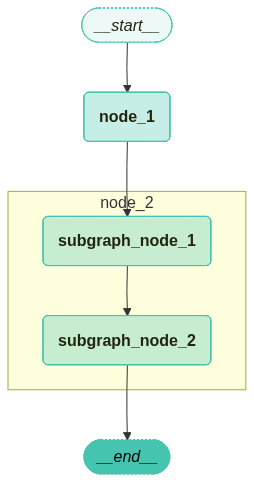

In [6]:
from langchain_teddynote.graphs import visualize_graph

visualize_graph(graph, xray=True)

### 그래프 실행

컴파일된 그래프를 스트리밍 방식으로 실행합니다. `graph.stream()`을 사용하면 각 노드의 실행 결과를 청크(chunk) 단위로 순차적으로 받을 수 있습니다. 초기 입력으로 `name: "Teddy"`를 전달하면, `node_1`과 서브그래프(`node_2`)를 거쳐 최종 결과가 생성됩니다.

기본 스트리밍에서는 상위 그래프의 노드별 출력만 확인할 수 있으며, 서브그래프 내부의 중간 실행 결과는 표시되지 않습니다.

아래 코드는 그래프를 스트리밍 방식으로 실행하고 각 노드의 출력을 출력합니다.

In [7]:
# 그래프 스트림에서 청크 단위로 데이터 처리 및 각 청크 출력
for chunk in graph.stream({"name": "Teddy"}):
    print(chunk)

{'node_1': {'name': 'My name is Teddy'}}
{'node_2': {'name': 'My name is Teddy Lee'}}


위 출력에서 상위 그래프의 노드별 결과만 확인할 수 있습니다. `node_2`의 출력에는 서브그래프 전체 실행 결과인 `'My name is Teddy Lee'`가 포함되어 있지만, 서브그래프 내부의 중간 단계(`subgraph_node_1`, `subgraph_node_2`)는 보이지 않습니다.

서브그래프 내부의 노드별 중간 결과까지 확인하려면 스트리밍 시 `subgraphs=True` 파라미터를 추가합니다. 이 옵션을 사용하면 출력 형식이 `(네임스페이스 튜플, 상태 딕셔너리)` 형태로 변경됩니다. 빈 튜플 `()`은 상위 그래프에서 발생한 이벤트, `('node_2:...',)` 형태의 튜플은 서브그래프 내부에서 발생한 이벤트임을 의미합니다.

아래 코드는 `subgraphs=True` 옵션을 사용하여 서브그래프 내부의 실행 과정까지 포함한 전체 스트림 데이터를 출력합니다.

In [8]:
# 그래프 스트리밍 처리를 통한 서브그래프 데이터 청크 단위 순차 출력
# subgraphs 파라미터를 True로 설정하여 하위 그래프 포함 스트리밍 처리
for chunk in graph.stream({"name": "Teddy"}, subgraphs=True):
    print(chunk)

((), {'node_1': {'name': 'My name is Teddy'}})
(('node_2:22e60fae-1c9e-3b34-154b-30612c268819',), {'subgraph_node_1': {'family_name': 'Lee'}})
(('node_2:22e60fae-1c9e-3b34-154b-30612c268819',), {'subgraph_node_2': {'name': 'My name is Teddy Lee'}})
((), {'node_2': {'name': 'My name is Teddy Lee'}})


## Case 2: 스키마 키를 공유하지 않는 경우

더 복잡한 시스템에서는 상위 그래프와 완전히 다른 스키마를 가진 서브그래프가 필요할 수 있습니다. 이처럼 공유되는 상태 키가 전혀 없는 경우, Case 1의 방식(컴파일된 서브그래프를 직접 노드로 추가)은 사용할 수 없습니다.

이 경우에는 **서브그래프를 호출하는 노드 함수**를 직접 정의해야 합니다. 노드 함수 내부에서 다음 두 가지 변환 작업을 수행합니다.

1. **호출 전**: 상위 상태(Parent State)를 서브그래프 상태(Child State) 형식으로 변환하여 서브그래프에 전달
2. **호출 후**: 서브그래프의 응답을 다시 상위 상태(Parent State) 형식으로 변환하여 반환

이 방식은 더 많은 코드가 필요하지만, 두 그래프 간의 완전한 독립성을 보장하면서 유연한 상태 변환이 가능하다는 장점이 있습니다.

아래 코드에서는 서로 다른 스키마를 가진 서브그래프와 부모 그래프를 정의하고, 노드 함수를 통해 두 그래프를 연결합니다.

**참고: 동일 노드 내 서브그래프 중복 호출 제한**

동일한 노드 함수 내에서 두 개 이상의 서브그래프를 호출할 수 **없습니다**. 이는 LangGraph가 스트리밍 시 서브그래프의 네임스페이스를 추적하는 방식에서 비롯된 기술적 제약입니다. 하나의 노드 내에서 여러 서브그래프를 호출하면 상태 네임스페이스가 충돌하여 예기치 않은 동작이 발생할 수 있습니다.

여러 서브그래프를 활용해야 한다면, 각 서브그래프 호출을 **별도의 노드 함수로 분리**하여 그래프에 등록하는 방식을 사용하세요.

In [9]:
# 서브그래프의 상태 타입 정의 (부모 그래프와 공유하는 키 없음)
class ChildState(TypedDict):
    name: str  # 서브그래프 내부에서만 사용되는 전용 상태 키


# 서브그래프의 첫 번째 노드: 입력받은 name(성) 앞에 이름을 붙여 full name 형태로 변환
def subgraph_node_1(state: ChildState):
    """서브그래프 첫 번째 노드

    입력받은 name(성) 앞에 이름 "Teddy"를 붙여 full name 형태로 만듭니다.
    예: "Lee" → "Teddy Lee"
    """
    return {"name": "Teddy " + state["name"]}


# 서브그래프의 두 번째 노드: name을 "My name is" 형식의 완성된 문장으로 변환
def subgraph_node_2(state: ChildState):
    """서브그래프 두 번째 노드

    name 값을 "My name is {name}" 형식의 완성된 문장으로 변환합니다.
    예: "Teddy Lee" → "My name is Teddy Lee"
    """
    return {"name": f'My name is {state["name"]}'}


# 서브그래프 빌더 초기화 및 노드 연결 구성
subgraph_builder = StateGraph(ChildState)
subgraph_builder.add_node(subgraph_node_1)
subgraph_builder.add_node(subgraph_node_2)
subgraph_builder.add_edge(START, "subgraph_node_1")
subgraph_builder.add_edge("subgraph_node_1", "subgraph_node_2")
subgraph = subgraph_builder.compile()


# 부모 그래프의 상태 타입 정의 (서브그래프와 공유하는 키 없음)
class ParentState(TypedDict):
    family_name: str  # 서브그래프에 전달할 성(姓) 값
    full_name: str    # 서브그래프 실행 결과를 저장할 최종 이름


# 부모 그래프의 첫 번째 노드: family_name 값을 그대로 전달
def node_1(state: ParentState):
    """부모 그래프 첫 번째 노드

    family_name 값을 그대로 반환합니다.
    실제 시스템에서는 이 단계에서 데이터 전처리 등의 작업을 수행할 수 있습니다.
    """
    return {"family_name": state["family_name"]}


# 부모 그래프의 두 번째 노드: 서브그래프를 직접 호출하여 상태를 변환하고 결과를 반환
def node_2(state: ParentState):
    """부모 그래프 두 번째 노드

    서브그래프를 직접 호출하여 상태를 변환합니다.
    1. 부모 상태(family_name)를 서브그래프 입력 형식(name)으로 변환하여 전달
    2. 서브그래프 응답(name)을 부모 상태 키(full_name)에 매핑하여 반환
    """
    # 부모 상태(family_name)를 서브그래프 입력 형식(name)으로 변환
    response = subgraph.invoke({"name": state["family_name"]})
    # 서브그래프 응답(name)을 부모 상태 키(full_name)에 매핑
    return {"full_name": response["name"]}


# 부모 그래프 빌더 초기화 및 노드 연결 구성
builder = StateGraph(ParentState)
builder.add_node("node_1", node_1)
# 컴파일된 서브그래프 대신 서브그래프를 호출하는 node_2 함수를 노드로 등록
builder.add_node("node_2", node_2)
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", END)
graph = builder.compile()

### 그래프 시각화

노드 함수를 통해 서브그래프를 호출하는 그래프를 시각화합니다. 이 경우 `node_2`는 단순한 노드로 표시되지만, 내부적으로 서브그래프를 호출합니다. 스키마가 다르기 때문에 서브그래프가 별도 노드로 표시되지 않습니다.

아래 코드는 그래프를 시각화합니다.

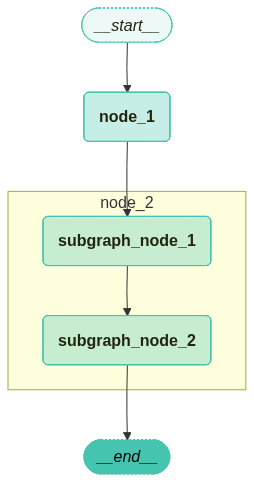

In [10]:
from langchain_teddynote.graphs import visualize_graph

visualize_graph(graph, xray=True)

### 그래프 실행

Case 2의 그래프를 스트리밍 방식으로 실행합니다. `family_name: "Lee"`를 초기 입력으로 전달하면, `node_1`에서 family_name을 처리하고, `node_2`에서 서브그래프를 호출하여 최종 결과(`full_name`)를 생성합니다.

`subgraphs=True` 옵션을 사용하면 `node_2` 내부에서 호출되는 서브그래프의 중간 실행 결과도 함께 확인할 수 있습니다. 출력의 네임스페이스 튜플에 `node_2:...` 형태의 ID가 포함되어 있어 서브그래프 내부에서 발생한 이벤트임을 식별할 수 있습니다.

아래 코드는 `subgraphs=True` 옵션으로 그래프를 실행하고 서브그래프 내부 실행 과정을 포함한 전체 출력을 확인합니다.

In [11]:
# 그래프 스트리밍 처리를 통한 서브그래프 데이터 청크 단위 순차 출력
# subgraphs=True 옵션으로 하위 그래프 포함하여 스트림 데이터 처리
for chunk in graph.stream({"family_name": "Lee"}, subgraphs=True):
    print(chunk)

((), {'node_1': {'family_name': 'Lee'}})
(('node_2:a54bd9a7-1ab8-746c-a979-89901baf9946',), {'subgraph_node_1': {'name': 'Teddy Lee'}})
(('node_2:a54bd9a7-1ab8-746c-a979-89901baf9946',), {'subgraph_node_2': {'name': 'My name is Teddy Lee'}})
((), {'node_2': {'full_name': 'My name is Teddy Lee'}})


## 정리

이 튜토리얼에서는 LangGraph의 서브그래프를 추가하고 활용하는 두 가지 방법을 살펴보았습니다.

**Case 1: 스키마 키를 공유하는 경우**
- 상위 그래프와 서브그래프가 동일한 상태 키를 공유할 때 사용합니다.
- 컴파일된 서브그래프 객체를 `.add_node()`에 직접 전달하여 노드로 등록합니다.
- 공유 키를 통해 상태가 자동으로 전달되므로 별도의 변환 코드가 필요 없습니다.

**Case 2: 스키마 키를 공유하지 않는 경우**
- 상위 그래프와 서브그래프의 상태 스키마가 완전히 다를 때 사용합니다.
- 서브그래프를 호출하는 노드 함수를 별도로 정의하고, 함수 내부에서 상태를 수동으로 변환합니다.
- 더 복잡하지만 그래프 간의 완전한 독립성을 보장하며 유연한 상태 변환이 가능합니다.

**서브그래프 스트리밍**
- 기본 스트리밍: 상위 그래프 노드의 출력만 확인
- `subgraphs=True`: 서브그래프 내부의 중간 실행 결과까지 포함하여 확인 가능